### Loading the DataSet

In [89]:
import pandas as pd
df=pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Understanding the DataSet

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


### Statistical Info of Data

In [91]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### Checking Missing Values

In [92]:
print("Null values")
df.isna().sum()

Null values


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Checking Duplicate Records

In [93]:
df.duplicated().sum()

np.int64(0)

### Removing trailing and leading white spaces from columns names

In [94]:
df.columns=df.columns.str.strip()

### Type Conversion

In [95]:
for i in df.select_dtypes(include='number').columns:
    df[i]=pd.to_numeric(df[i],errors='coerce')
print("Null values after Type conversion")
df.isna().sum()

Null values after Type conversion


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## EDA

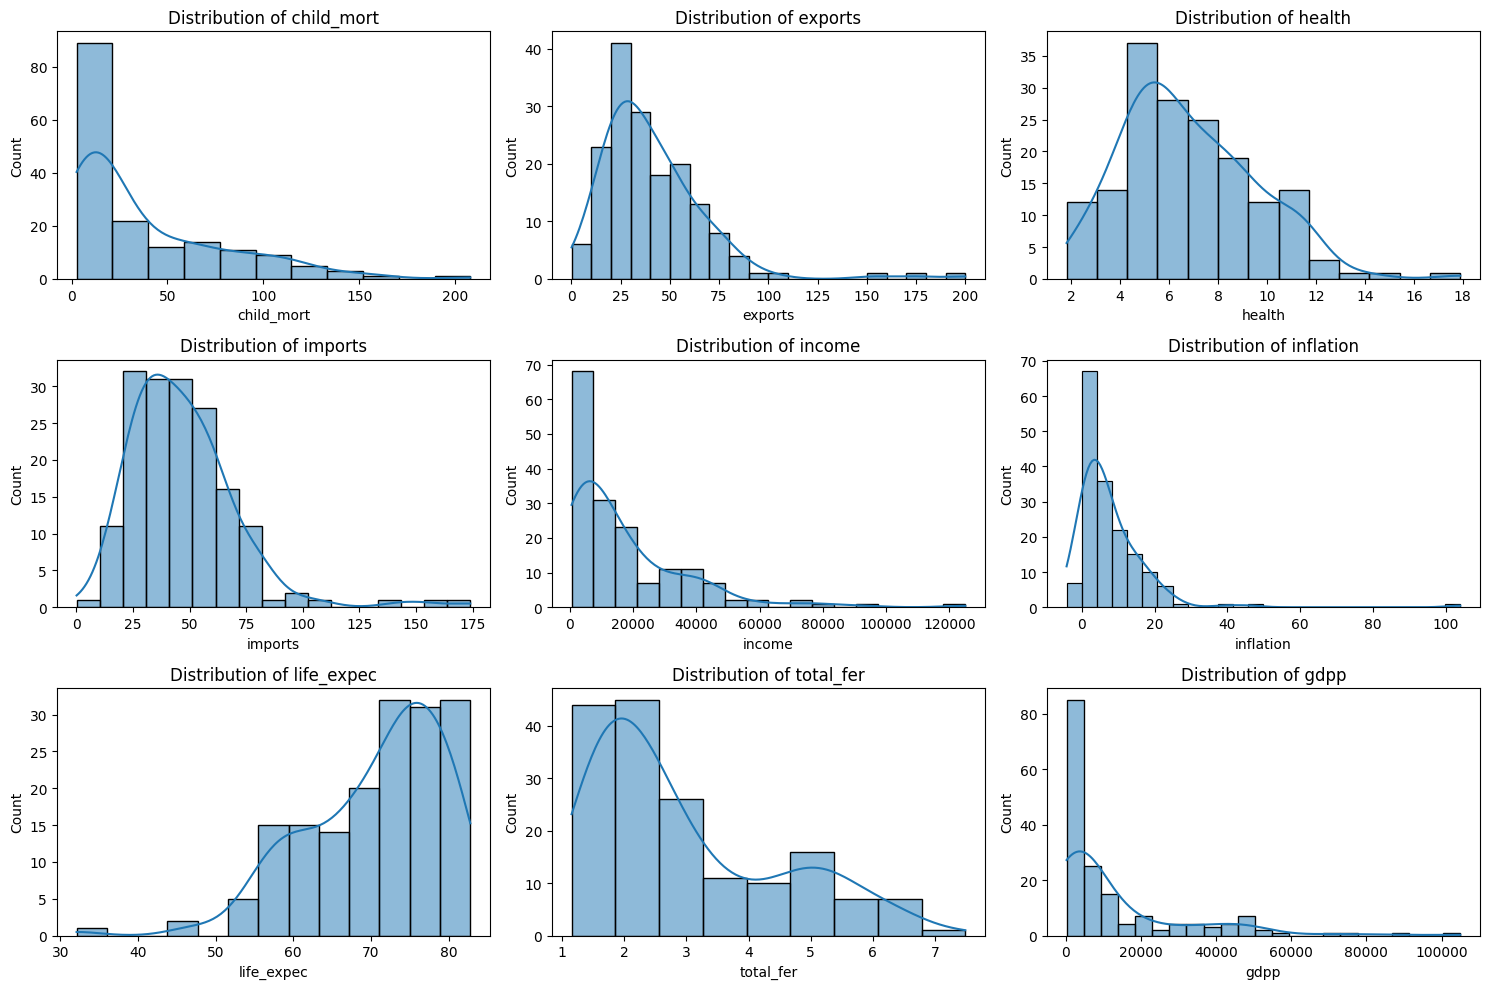

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,axes=plt.subplots(3,3,figsize=(15,10))
for ax,i in zip(axes.ravel(),df.select_dtypes(include='number').columns):
    sns.histplot(x=df[i],ax=ax,kde=True)
    ax.set_xlabel(i)
    ax.set_title(f'Distribution of {i}')
plt.tight_layout()
plt.show()

### Distribution Insights

- Most features are **right-skewed**, indicating the presence of countries with exceptionally high values.
- **Income**, **GDP per capita (gdpp)**, **child mortality**, and **inflation** exhibit strong positive skewness and contain extreme values.
- **Exports** and **imports** show moderate right skewness, suggesting variation in trade dependence across countries.
- **Life expectancy** is slightly negatively skewed, with most countries having relatively high life expectancy.
- **Total fertility rate** is positively skewed, indicating a few countries with very high fertility levels.
- The distributions highlight significant socioeconomic differences among countries, making the dataset suitable for clustering based on development indicators.

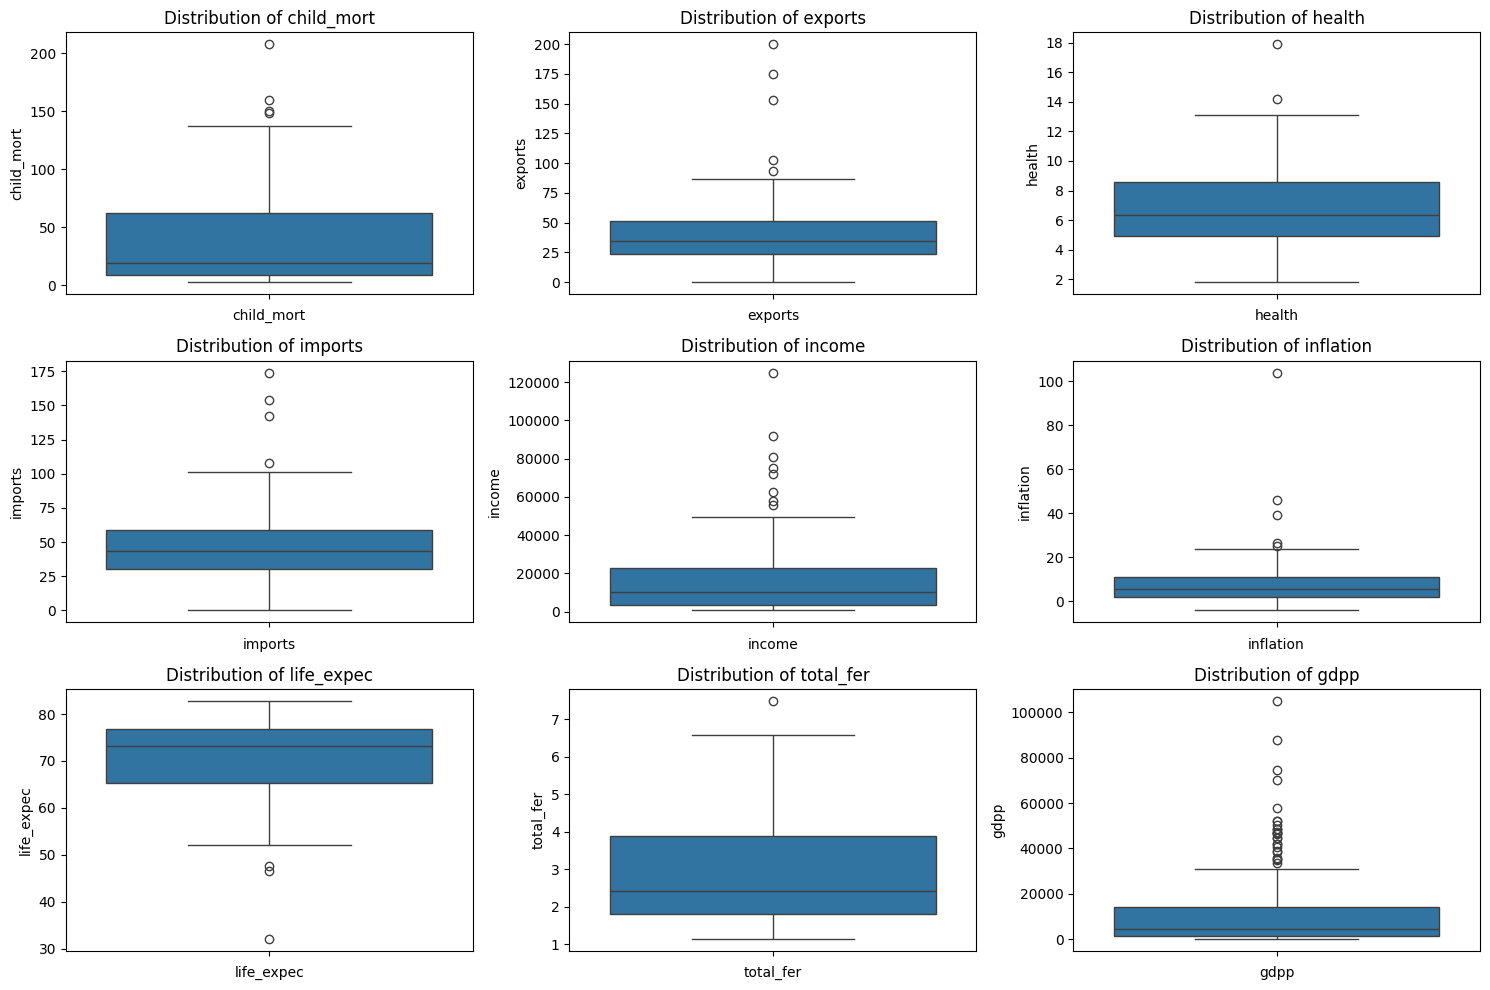

In [97]:
fig,axes=plt.subplots(3,3,figsize=(15,10))
for ax,i in zip(axes.ravel(),df.select_dtypes(include='number').columns):
    sns.boxplot(df[i],ax=ax)
    ax.set_xlabel(i)
    ax.set_title(f'Distribution of {i}')
plt.tight_layout()
plt.show()

### Outlier Analysis

- Several numerical features contain statistical outliers, particularly **income**, **gdpp**, **inflation**, **child_mort**, **exports**, and **imports**.
- These outliers represent countries with exceptionally high economic output, trade activity, inflation rates, or mortality levels.
- Although identified as outliers by the IQR method, these observations are **valid real-world values** and not data entry errors.
- Since the objective is country segmentation, removing these observations could result in the loss of important information about highly developed or underdeveloped nations.
- Therefore, outliers were retained and handled through feature scaling before clustering.

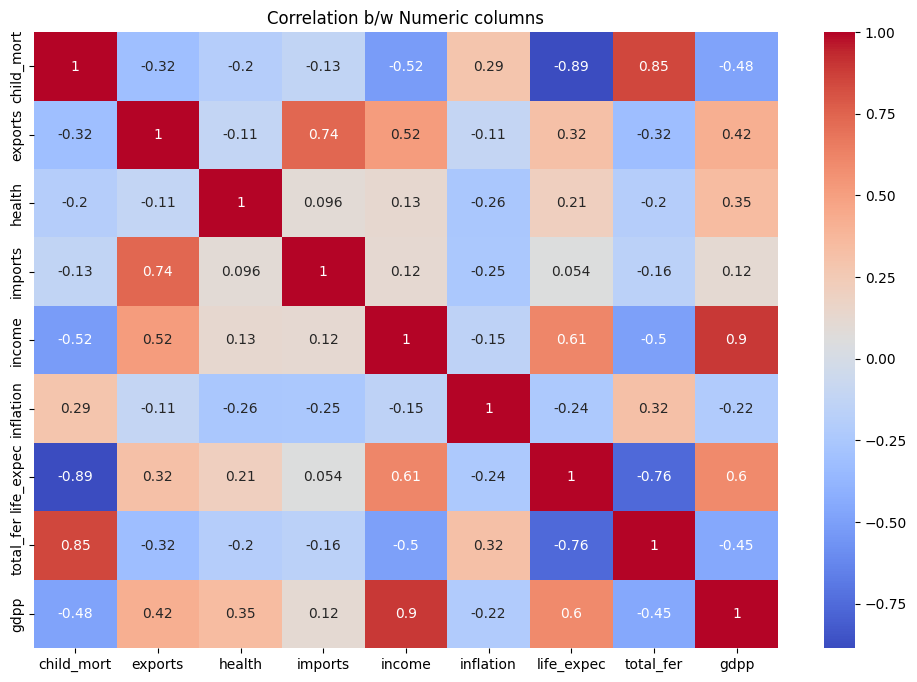

In [98]:
plt.figure(figsize=(12,8))
plt.title('Correlation b/w Numeric columns')
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

### Correlation Analysis

- **Income** and **GDP per capita (gdpp)** show a very strong positive correlation (**0.90**), indicating that wealthier countries generally have higher economic output per person.
- **Child mortality** and **life expectancy** exhibit a strong negative correlation (**-0.89**), suggesting that countries with higher child mortality tend to have lower life expectancy.
- **Child mortality** and **fertility rate** are strongly positively correlated (**0.85**), indicating that countries with high mortality rates often have higher birth rates.
- **Life expectancy** and **fertility rate** show a strong negative relationship (**-0.76**), reflecting lower fertility rates in more developed nations.
- **Exports** and **imports** are highly correlated (**0.74**), suggesting that countries actively engaged in global trade tend to both export and import more.
- Overall, the correlation patterns indicate that the dataset is primarily driven by a country's level of socioeconomic development, making it well-suited for clustering and segmentation.

In [99]:
x=df.drop(columns='country')

In [101]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=pd.DataFrame(sc.fit_transform(x),columns=x.columns)
x_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Feature Scaling

- Clustering algorithms are sensitive to feature scales because they rely on distance calculations.
- Variables such as **income** and **gdpp** have much larger magnitudes than features like **health** and **total_fer**.
- Therefore, **StandardScaler** was applied to standardize all features and ensure equal contribution during clustering.

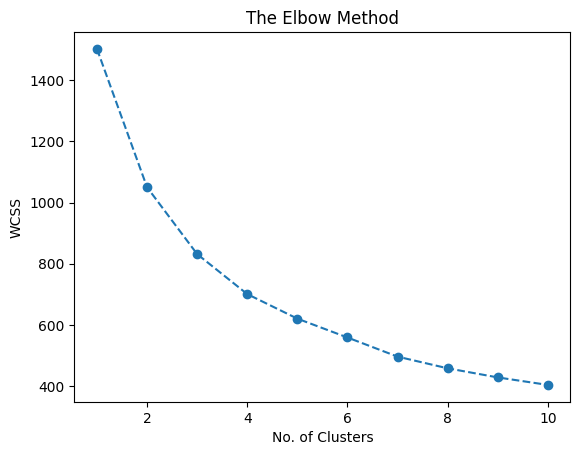

In [159]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',n_init=10,random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

In [154]:
optimal_k = 3
kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=42
)
kmeans_labels = kmeans.fit_predict(x_scaled)
df['KMeans_Clusters'] = kmeans_labels

### Selection of Optimal Number of Clusters

- The Elbow Method indicates a noticeable bend around **k = 3–4**, after which the reduction in WCSS becomes less significant.
- Based on the elbow curve and cluster interpretability, **k = 3** was chosen as the optimal number of clusters.
- This choice produces meaningful and balanced country segments without creating very small clusters.

In [155]:
df['KMeans_Clusters'].value_counts()


KMeans_Clusters
2    84
1    47
0    36
Name: count, dtype: int64

## Cluster Distribution Observation

The K-Means model distributed the 167 countries across three clusters:

- **Cluster 2:** 84 countries
- **Cluster 1:** 47 countries
- **Cluster 0:** 36 countries

The distribution indicates that the dataset contains a large group of countries with similar characteristics, along with two smaller but distinct socio-economic segments.

In [122]:
df[['country','KMeans_Clusters']].head()

,country,KMeans_Clusters
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## K-Means Clustering Observation

A K-Means clustering model was trained with **3 clusters** to segment countries based on their socio-economic characteristics.

Each country was assigned to a cluster according to similarities in indicators such as income, GDP per capita, child mortality, life expectancy, fertility rate, trade activity, and inflation.

The resulting clusters represent distinct levels of socioeconomic development and will be further analyzed to identify high-development, emerging, and low-development country groups.

In [108]:
from sklearn.metrics import silhouette_score
sil_score=silhouette_score(x_scaled,df['KMeans_Clusters'])
print("Silhouette Score:", round(sil_score,4))

Silhouette Score: 0.2833


## Clustering Performance Observation

The K-Means model achieved a **Silhouette Score of 0.2833**.

This positive score indicates reasonable cluster formation, with countries within the same cluster sharing similar socio-economic characteristics.

Although the clusters are not perfectly separated, the result is acceptable for real-world country-level data where significant overlap naturally exists.

In [106]:
Kmean_clustering_Summary=df.groupby('KMeans_Clusters').mean(numeric_only=True)
Kmean_clustering_Summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Clusters,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


## Cluster Profile Observation

- **Cluster 0** represents highly developed countries with the highest income, GDP per capita, and life expectancy, along with the lowest child mortality and fertility rates.
- **Cluster 1** represents the least developed countries, characterized by low income, low GDP per capita, high child mortality, and high fertility rates.
- **Cluster 2** represents developing countries with moderate economic and health indicators.

Overall, the clusters clearly capture different levels of socioeconomic development.

In [116]:
from sklearn.cluster._dbscan import DBSCAN
eps=[0.5,1,1.5]
min_samples=[3,4,5]

for ep in eps:
    for ms in min_samples:
        print(f"DBSCAN for eps={ep}, min_samples={ms}")

        db=DBSCAN(eps=ep,min_samples=ms)
        labels=db.fit_predict(x_scaled)

        unq_labels=set(labels)
        n_clusters=len(unq_labels)-(1 if -1 in unq_labels else 0)

        noise_points=list(labels).count(-1)
        noise_ratio=noise_points/len(labels)

        print("no. of clusters: ",n_clusters)
        print("noise points ratio: ",round(noise_ratio,3))

        if n_clusters>=2:
            mask=labels!=-1
            print(f"silhouette score: {round(silhouette_score(x_scaled[mask],labels[mask]),3)}\n")

DBSCAN for eps=0.5, min_samples=3
no. of clusters:  1
noise points ratio:  0.97
DBSCAN for eps=0.5, min_samples=4
no. of clusters:  0
noise points ratio:  1.0
DBSCAN for eps=0.5, min_samples=5
no. of clusters:  0
noise points ratio:  1.0
DBSCAN for eps=1, min_samples=3
no. of clusters:  6
noise points ratio:  0.431
silhouette score: 0.309

DBSCAN for eps=1, min_samples=4
no. of clusters:  4
noise points ratio:  0.503
silhouette score: 0.344

DBSCAN for eps=1, min_samples=5
no. of clusters:  3
noise points ratio:  0.563
silhouette score: 0.434

DBSCAN for eps=1.5, min_samples=3
no. of clusters:  2
noise points ratio:  0.15
silhouette score: 0.226

DBSCAN for eps=1.5, min_samples=4
no. of clusters:  1
noise points ratio:  0.174
DBSCAN for eps=1.5, min_samples=5
no. of clusters:  1
noise points ratio:  0.18


## DBSCAN Parameter Tuning Observation

- Small values of **eps (0.5)** resulted in almost all countries being classified as noise.
- Increasing **eps to 1.0** produced multiple clusters with higher silhouette scores but also a large proportion of noise points.
- The highest silhouette score (**0.434**) was achieved with **eps = 1.0** and **min_samples = 5**, though over 56% of countries were treated as noise.
- A more balanced solution was obtained with **eps = 1.5** and **min_samples = 3**, which formed 2 clusters while retaining most countries in the clustering process.

In [117]:
dbscan=DBSCAN(
    eps=1.5,
    min_samples=3
)
dbscan_labels = dbscan.fit_predict(x_scaled)
df['DBSCAN_Cluster'] = dbscan_labels
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    139
-1     25
 1      3
Name: count, dtype: int64


In [120]:
print("No.of DBSCAN Clusters: ",df['DBSCAN_Cluster'].nunique()-1)
print("No.of Noise Points: ",df.loc[df['DBSCAN_Cluster']==-1].shape[0])

No.of DBSCAN Clusters:  2
No.of Noise Points:  25


In [121]:
df[['country','DBSCAN_Cluster']].head()

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0


In [127]:
mask=df['DBSCAN_Cluster']!=-1
print(f"silhouette score: {round(silhouette_score(x_scaled[mask],df.loc[mask,'DBSCAN_Cluster']),3)}\n")

silhouette score: 0.226



## DBSCAN Performance Observation

The DBSCAN model achieved a Silhouette Score of **0.226**.

While the cluster separation is moderate, the model successfully grouped most countries into two clusters with only a small proportion of noise points, resulting in a practical and interpretable segmentation.

In [131]:
DBSCAN_clustering_Summary=df.groupby('DBSCAN_Cluster').mean(numeric_only=True).drop(columns='KMeans_Clusters')
DBSCAN_clustering_Summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
DBSCAN_Cluster,,,,,,,,,
-1,62.248000,60.640000,6.427200,55.372000,29079.480000,16.662960,66.720000,3.574800,21220.560000
0,33.402158,38.081288,6.764317,44.552992,15326.661871,6.274835,71.423741,2.810216,11725.345324
1,64.000000,18.633333,12.433333,84.500000,1923.333333,3.596667,62.300000,4.106667,1559.000000


## DBSCAN Cluster Profile Observation

- **Cluster 0** contains the majority of countries and represents nations with moderate income, GDP per capita, life expectancy, and child mortality levels.
- **Cluster 1** consists of a small group of low-income countries characterized by low GDP per capita, high imports, high fertility rates, and lower life expectancy.
- The **noise group (-1)** contains countries with unusual socio-economic characteristics that do not fit well into the identified clusters.
- Overall, DBSCAN successfully identified both common country patterns and outlier countries within the dataset.

In [132]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
print(x_pca.shape)

(167, 2)


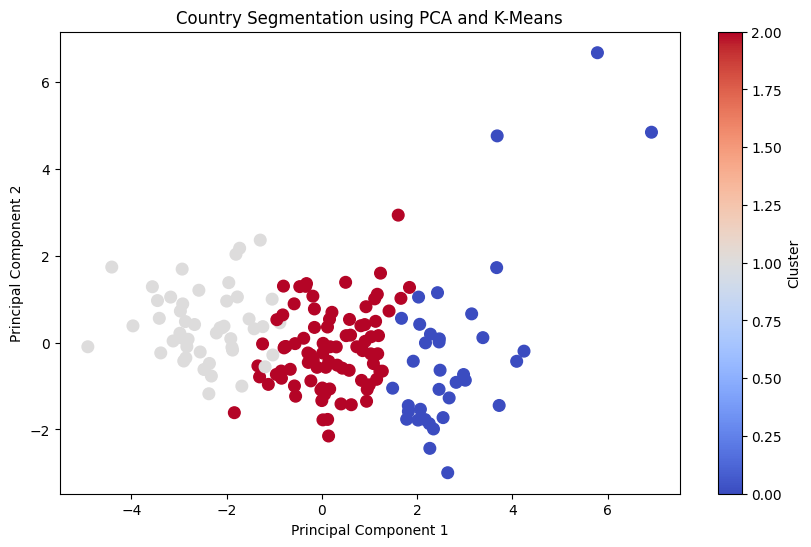

In [134]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=kmeans_labels,
    cmap='coolwarm',
    s=70
)

plt.title('Country Segmentation using PCA and K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter,label='Cluster')

plt.show()

## PCA Visualization Observation

- The PCA plot shows that countries are grouped into three distinct clusters.
- Most countries within the same cluster are located close to each other, indicating similar socio-economic characteristics.
- Some overlap exists between clusters, which is expected in real-world country data.
- Overall, the visualization confirms that K-Means was able to identify meaningful country segments.

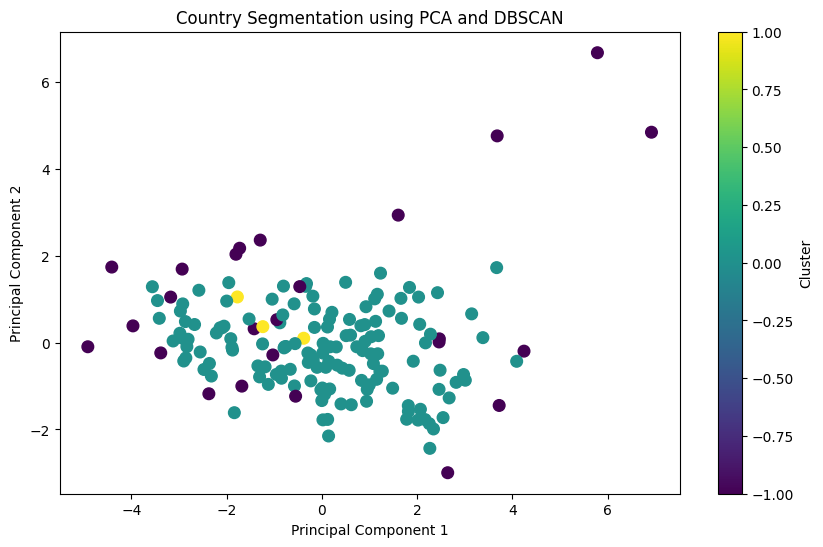

In [137]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=dbscan_labels,
    cmap='viridis',
    s=70
)

plt.title('Country Segmentation using PCA and DBSCAN')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter,label='Cluster')

plt.show()

## DBSCAN PCA Visualization Observation

- DBSCAN formed two clusters and identified several noise points.
- The main cluster contains the majority of countries, while a smaller cluster captures countries with distinct characteristics.
- Noise points represent countries with unusual socio-economic profiles.
- The visualization demonstrates DBSCAN's ability to detect both clusters and outliers.

# Section 14: Country Segmentation Insights

### Observation 1: High-Mortality and Low-Income Countries

Cluster 1 represents the least developed countries, characterized by the highest child mortality rate (92.96), lowest income levels (3942), lowest GDP per capita (1922), and lowest life expectancy (59.19 years). These countries face significant economic and healthcare challenges.

### Observation 2: Highly Developed Economies

Cluster 0 consists of highly developed countries with the highest average income (45672), highest GDP per capita (42494), highest life expectancy (80.13 years), and lowest child mortality rate (5.0). These countries demonstrate strong economic growth and healthcare outcomes.

### Observation 3: Developing Countries

Cluster 2 represents developing economies with moderate income levels (12306), GDP per capita (6486), and life expectancy (72.81 years). These countries show better socio-economic conditions than Cluster 1 but remain below the development level of Cluster 0.

### Observation 4: Meaningful Cluster Formation

The PCA visualization showed a reasonable separation among the three clusters, indicating that economic, health, and demographic indicators effectively differentiate countries based on their development status.

### Observation 5: Effective Country Segmentation

The K-Means model achieved a Silhouette Score of 0.2833, indicating moderate cluster separation. Despite some overlap, the clustering successfully identified distinct groups of countries with different socio-economic characteristics.

In [138]:
from sklearn.model_selection import train_test_split

x_clf = x.copy()

y_clf = df['KMeans_Clusters']

X_train, X_test, y_train, y_test = train_test_split(
    x_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


In [140]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold,cross_val_score

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='f1_macro'
    )

    print(f'\n{name}')
    print('CV Scores:', scores)
    print('Mean F1 Macro:', round(scores.mean(),3))


Random Forest
CV Scores: [0.96286472 1.         0.9244481  0.9620133  0.9654321 ]
Mean F1 Macro: 0.963

AdaBoost
CV Scores: [0.96286472 1.         0.9244481  0.92024642 0.88859416]
Mean F1 Macro: 0.939

XGBoost
CV Scores: [0.96286472 0.95735129 0.95735129 0.9620133  0.9654321 ]
Mean F1 Macro: 0.961

LightGBM
CV Scores: [1.         0.87205387 0.95735129 0.9620133  0.92857143]
Mean F1 Macro: 0.944


## Ensemble Model Comparison

- Stratified 5-Fold Cross-Validation was used to evaluate the ensemble classifiers.
- Random Forest achieved the highest mean F1-Macro score (**0.963**), followed closely by XGBoost (**0.961**).
- AdaBoost and LightGBM also showed strong performance with scores above **0.93**.
- The results indicate that the cluster labels can be accurately predicted using the socio-economic features.

In [141]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train,y_train)

print("Best RF Params:",rf_grid.best_params_)
print("Best RF CV Score:",rf_grid.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV Score: 0.9471926838593504


In [142]:
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1]
}
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_grid=xgb_params,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV Score:", xgb_grid.best_score_)

Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV Score: 0.9610025393933441


## Hyperparameter Tuning Results

The two best-performing models from cross-validation, **Random Forest** and **XGBoost**, were further optimized using Grid Search with Stratified 5-Fold Cross-Validation.

- The tuned **Random Forest** model achieved a Mean F1-Macro score of **0.947**.
- The tuned **XGBoost** model achieved a Mean F1-Macro score of **0.961**.

### Observation

- Both models demonstrated strong predictive performance after tuning.
- XGBoost achieved the highest cross-validation score and outperformed Random Forest.
- Based on these results, **XGBoost was selected as the final classification model** for predicting cluster membership.

In [143]:
best_xgb = xgb_grid.best_estimator_
y_pred = best_xgb.predict(X_test)

In [144]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:",round(accuracy_score(y_test,y_pred),3))
print("Precision:",round(precision_score(y_test,y_pred,average='macro'),3))
print("Recall:",round(recall_score(y_test,y_pred,average='macro'),3))
print("F1:",round(f1_score(y_test,y_pred,average='macro'),3))
print(classification_report(y_test,y_pred))

Accuracy: 0.971
Precision: 0.981
Recall: 0.967
F1: 0.973
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## Final Model Evaluation (XGBoost)

The tuned XGBoost model was evaluated on the held-out test set.

- Accuracy: **97.1%**
- Precision (Macro): **98.1%**
- Recall (Macro): **96.7%**
- F1-Score (Macro): **97.3%**

The model demonstrated excellent predictive performance and was able to accurately classify countries into their respective socio-economic clusters.

## Supervised Learning Extension

Since the dataset lacked a target variable, K-Means cluster labels were used as pseudo-labels for supervised learning.

Random Forest, AdaBoost, XGBoost, and LightGBM models were trained and compared to predict cluster membership, with XGBoost achieving the best overall performance.